# Study Buddy — now with a web-searching Researcher agent

Three agents collaborate to teach you a topic:

1. **Researcher agent** — searches the web (DuckDuckGo, free, no API key) and summarizes what it finds into research notes.
2. **Explainer agent** — writes a student-friendly explanation *based on those notes*.
3. **Reviewer agent** — grades it. Unclear → feedback + loop back to the Explainer. Good → 3-question quiz, done.

```
  START     +------------+     +-----------+     +----------+  approved   END
  --------->| RESEARCHER |---->| EXPLAINER |---->| REVIEWER |------------>
            | (searches  |     |           |     |          |
            |  the web)  |     +-----------+     +----------+
            +------------+           ^                |
                                     |   needs work   |
                                     +----------------+
                                      (max 2 revisions)
```

**Design decision to notice:** the rejection loop goes back to the *Explainer*, not the Researcher. The facts didn't change — only the writing needs fixing. Deciding which node a loop returns to is a real agent-design skill.

Works in Jupyter or **Google Colab**. You need a free Gemini API key from [Google AI Studio](https://aistudio.google.com/).

## Step 0 — Install dependencies

`ddgs` is the DuckDuckGo search library — our Researcher's tool.

In [ ]:
%pip install -q langgraph langchain-google-genai ddgs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.7/70.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 61.4 MB/s eta 0:00:00


## Step 1 — API key, LLM, and a text helper

We use `gemini-3.1-flash-lite`: cheap, fast, and stable — ideal for a project that calls the API in a loop. `max_output_tokens=4096` gives plenty of headroom so answers never get cut off mid-sentence.

In [ ]:
import os, getpass

if "GOOGLE_API_KEY" not in os.environ:
    os.environ["GOOGLE_API_KEY"] = getpass.getpass("Enter your Gemini API key: ")

from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite", max_output_tokens=4096)

def get_text(response) -> str:
    """
      Return the response as plain text.

      Some Gemini models return .content as a LIST of blocks
      (thinking blocks + text blocks) instead of a plain string.
      This helper handles both cases so our agents never crash.
    """
    content = response.content
    if isinstance(content, str):
        return content
    parts = []
    for block in content:
        if isinstance(block, str):
            parts.append(block)
        elif isinstance(block, dict) and block.get("type") == "text":
            parts.append(block.get("text", ""))
    return "".join(parts)

# Quick smoke test — one plain LLM call, no graph yet:
print(get_text(llm.invoke("Say hello in 5 words.")))

Enter your Gemini API key: ··········
Hello, it is nice meeting.


## Step 2 — The STATE (our shared "worksheet")

One new blank compared to v1: `research_notes`. The Researcher writes it, the Explainer reads it. That's how agents communicate — never directly, always through the state.

In [ ]:
from typing import TypedDict

class StudyState(TypedDict):
    topic: str            # what the student wants to learn
    research_notes: str   # NEW: written by the Researcher agent
    explanation: str      # written by the Explainer agent
    feedback: str         # written by the Reviewer agent (empty if approved)
    quiz: str             # written by the Reviewer agent once approved
    revisions: int        # loop counter so we never revise forever

## Step 3 — Agent 1: the Researcher (NEW)

This agent has a **tool**: web search. The pattern is the important lesson here —

1. use the tool (search) to gather raw material,
2. use the LLM to turn raw material into something useful (clean notes),
3. write the result into the state.

We wrap the search in `try/except` so the whole graph still works even if the search service is unavailable — agents should degrade gracefully, not crash.

In [ ]:
from ddgs import DDGS

def researcher_agent(state: StudyState) -> dict:
    """Searches the web for the topic and distills the results into notes."""
    print(f"[Researcher] searching the web for '{state['topic']}'...")

    # --- 1. Use the TOOL: web search ---
    try:
        results = DDGS().text(state["topic"], max_results=5)
        raw = "\n\n".join(
            f"Source: {r['title']}\n{r['body']}" for r in results
        )
    except Exception as e:
        print(f"[Researcher] search failed ({e}) — continuing without notes.")
        return {"research_notes": ""}

    # --- 2. Use the LLM: turn raw search results into clean notes ---
    prompt = (
        f"Here are web search results about '{state['topic']}':\n\n{raw}\n\n"
        "Write 5-8 bullet points of the most important, accurate facts "
        "a teacher would need to explain this topic. Facts only, no fluff."
    )
    notes = get_text(llm.invoke(prompt))

    print("[Researcher] notes ready.")
    # --- 3. Write into the state ---
    return {"research_notes": notes}

## Step 4 — Agent 2: the Explainer

Almost identical to v1 — the one change is that its prompt now includes the research notes, so it explains from *sourced facts* instead of pure memory.

In [ ]:
def explainer_agent(state: StudyState) -> dict:
    """Writes (or rewrites) an explanation of the topic using the research notes."""
    print(f"[Explainer] writing explanation (revision #{state['revisions']})...")

    notes_part = ""
    if state["research_notes"]:
        notes_part = (
            "\nBase your explanation on these research notes:\n"
            f"{state['research_notes']}\n"
        )

    feedback_part = ""
    if state["feedback"]:
        feedback_part = (
            "\nA reviewer said your previous draft had these problems:\n"
            f"{state['feedback']}\n"
            "Rewrite the explanation and fix every problem."
        )

    prompt = (
        f"Explain the topic '{state['topic']}' to a high-school student.\n"
        "Rules: under 200 words, use one everyday analogy, no jargon "
        "without defining it." + notes_part + feedback_part
    )

    response = llm.invoke(prompt)
    return {
        "explanation": get_text(response),
        "revisions": state["revisions"] + 1,
    }

## Step 5 — Agent 3: the Reviewer / Quiz-Master

Unchanged from v1.

In [ ]:
def reviewer_agent(state: StudyState) -> dict:
    """Grades the explanation. Approves it (and writes a quiz) or rejects it."""
    print("[Reviewer] grading the explanation...")

    prompt = (
        "You are a strict but fair teacher reviewing an explanation "
        f"of '{state['topic']}' written for a high-school student.\n\n"
        f"EXPLANATION:\n{state['explanation']}\n\n"
        "If it is clear, accurate, and beginner-friendly, reply with exactly:\n"
        "APPROVED\n"
        "followed by a 3-question multiple-choice quiz about the topic "
        "(include the answer key at the end).\n\n"
        "If it is NOT good enough, reply with exactly:\n"
        "REJECTED\n"
        "followed by a short bullet list of what to fix."
    )

    verdict = get_text(llm.invoke(prompt))

    if verdict.strip().upper().startswith("APPROVED"):
        print("[Reviewer] approved! Quiz generated.")
        quiz = verdict.split("\n", 1)[1] if "\n" in verdict else ""
        return {"feedback": "", "quiz": quiz}

    print("[Reviewer] rejected — sending feedback back to the Explainer.")
    feedback = verdict.split("\n", 1)[1] if "\n" in verdict else verdict
    return {"feedback": feedback, "quiz": ""}

## Step 6 — The router (conditional edge)

Unchanged. Note what it does NOT do: it never routes back to the Researcher. Research happens exactly once per run.

In [ ]:
from langgraph.graph import END

def route_after_review(state: StudyState) -> str:
    approved = state["quiz"] != ""
    out_of_tries = state["revisions"] >= 2  # max 2 rewrites

    if approved or out_of_tries:
        return END

    return "explainer"  # loop back for a rewrite (NOT back to research)

## Step 7 — Build the graph

One new node and one new edge compared to v1. Everything else is identical — that's the beauty of graphs: adding an agent is additive, you don't rewrite the system.

In [ ]:
from langgraph.graph import StateGraph, START

graph = StateGraph(StudyState)

graph.add_node("researcher", researcher_agent)   # NEW
graph.add_node("explainer", explainer_agent)
graph.add_node("reviewer", reviewer_agent)

graph.add_edge(START, "researcher")              # NEW: research first
graph.add_edge("researcher", "explainer")        # NEW: notes go to the writer
graph.add_edge("explainer", "reviewer")
graph.add_conditional_edges(
    "reviewer",
    route_after_review,
    {"explainer": "explainer", END: END},
)

app = graph.compile()

### Bonus: visualize the graph

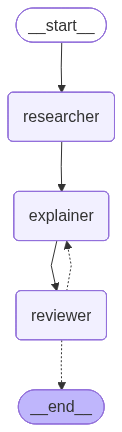

In [ ]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    print(app.get_graph().draw_ascii())

## Step 8 — Run it!

Try a topic where fresh web info actually matters — that's where the Researcher earns its place.

In [ ]:
topic = "photosynthesis"   # <-- try your own topic!

initial_state = {
    "topic": topic,
    "research_notes": "",
    "explanation": "",
    "feedback": "",
    "quiz": "",
    "revisions": 0,
}

final_state = app.invoke(initial_state)

print("\n" + "=" * 60)
print("RESEARCH NOTES:\n")
print(final_state["research_notes"])
print("\n" + "=" * 60)
print(f"FINAL EXPLANATION of '{topic}':\n")
print(final_state["explanation"])
print("\n" + "=" * 60)
if final_state["quiz"]:
    print("QUIZ:\n")
    print(final_state["quiz"])
else:
    print("(Reviewer never approved — stopped at the revision cap.)")

[Researcher] searching the web for 'photosynthesis'...
[Researcher] notes ready.
[Explainer] writing explanation (revision #0)...
[Reviewer] grading the explanation...
[Reviewer] approved! Quiz generated.

RESEARCH NOTES:

Here are the most important, accurate facts regarding photosynthesis:

*   Photosynthesis is a biological process used by autotrophs—including plants, algae, and cyanobacteria—to convert light energy into chemical energy stored in organic compounds like glucose.
*   In oxygenic photosynthesis, light energy is used to split water molecules, releasing oxygen as a byproduct and providing electrons for energy conversion.
*   Light-dependent reactions occur in reaction centers where pigments, such as chlorophyll, absorb light to generate ATP and NADPH.
*   The Calvin cycle (light-independent reactions) uses the ATP and NADPH produced in the light-dependent reactions to fix atmospheric carbon dioxide into organic sugars.
*   While most photosynthesis is oxygenic, some bact

### Bonus: watch the agents step by step

In [ ]:
for step in app.stream(initial_state):
    for node_name, updates in step.items():
        print(f"--- after node '{node_name}' ---")
        print({k: (v[:80] + "..." if isinstance(v, str) and len(v) > 80 else v)
               for k, v in updates.items()})
        print()

[Researcher] searching the web for 'photosynthesis'...
[Researcher] notes ready.
--- after node 'researcher' ---
{'research_notes': 'Here are the most important facts about photosynthesis for educational purposes:...'}

[Explainer] writing explanation (revision #0)...
--- after node 'explainer' ---
{'explanation': 'Think of photosynthesis as nature’s solar-powered bakery. Just as a bakery uses ...', 'revisions': 1}

[Reviewer] grading the explanation...
[Reviewer] approved! Quiz generated.
--- after node 'reviewer' ---
{'feedback': '', 'quiz': '\n**Quiz: Photosynthesis Review**\n\n1. What is the primary role of chlorophyll in ...'}



## Exercises for students

1. Make the Reviewer also check the explanation *against the research notes* (catch hallucinations!).
2. Add a conditional edge after the Researcher: if the notes are empty, skip straight to the Explainer with a warning in the state.
3. Let the Reviewer send a rejection back to the **Researcher** instead, when the problem is "missing facts" rather than "bad writing" — this needs the Reviewer to output *which kind* of problem it found.
4. Swap DuckDuckGo for a different tool (Wikipedia API, arXiv search) and compare note quality.

**Docs:** [LangGraph](https://langchain-ai.github.io/langgraph/) · [ddgs on PyPI](https://pypi.org/project/ddgs/)